# Sales Forecasting

## Business Problem

Forecasting future sales helps businesses estimate future revenue, plan inventory, allocate resources, and support strategic decision-making.

In this case study, we will build a simple forecasting model using historical monthly revenue data.

The goal is not to create the most accurate model, but to demonstrate the complete forecasting workflow:

- Prepare a time series
- Split the data into training and testing sets
- Train a forecasting model
- Evaluate prediction accuracy
- Interpret the business results

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
sales = pd.read_csv(
    "../06_Datasets/processed/dashboard_dataset.csv",
    parse_dates=["purchase_date"]
)

sales.head()

,order_id,purchase_date,order_status,customer_unique_id,customer_state,seller_id,product_category_name_english,price,freight_value,delivery_days,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,2017-09-13,delivered,871766c5855e863f6eccc05f988b23cb,RJ,48436dade18ac8b2bce089ec2a041202,cool_stuff,58.90,13.29,7.0,5.0
1,00018f77f2f0320c557190d7a144bdd3,2017-04-26,delivered,eb28e67c4c0b83846050ddfb8a35d051,SP,dd7ddc04e1b6c2c614352b383efe2d36,pet_shop,239.90,19.93,16.0,4.0
2,000229ec398224ef6ca0657da4fc703e,2018-01-14,delivered,3818d81c6709e39d06b2738a8d3a2474,MG,5b51032eddd242adc84c38acab88f23d,furniture_decor,199.00,17.87,7.0,5.0
3,00024acbcdf0a6daa1e931b038114c75,2018-08-08,delivered,af861d436cfc08b2c2ddefd0ba074622,SP,9d7a1d34a5052409006425275ba1c2b4,perfumery,12.99,12.79,6.0,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,2017-02-04,delivered,64b576fb70d441e8f1b2d7d446e483c5,SP,df560393f3a51e74553ab94004ba5c87,garden_tools,199.90,18.14,25.0,5.0


In [7]:
# Recreate revenue metric for forecasting
sales["revenue"] = sales["price"] + sales["freight_value"]

In [6]:
# Create revenue column
sales["revenue"] = sales["price"] + sales["freight_value"]

# Aggregate monthly revenue
monthly_revenue = (
    sales
    .groupby(
        pd.Grouper(
            key="purchase_date",
            freq="MS"
        )
    )["revenue"]
    .sum()
    .reset_index()
)

display(monthly_revenue.head())

,purchase_date,revenue
0,2016-09-01,354.75
1,2016-10-01,56808.84
2,2016-11-01,0.00
3,2016-12-01,19.62
4,2017-01-01,137188.49


In [8]:
# Split into training and testing sets
train = monthly_revenue.iloc[:-3]
test = monthly_revenue.iloc[-3:]

display(train.tail())

display(test)

,purchase_date,revenue
17,2018-02-01,986908.96
18,2018-03-01,1155126.82
19,2018-04-01,1159698.04
20,2018-05-01,1149781.82
21,2018-06-01,1022677.11


,purchase_date,revenue
22,2018-07-01,1058728.03
23,2018-08-01,1003308.47
24,2018-09-01,166.46


In [9]:
# Create numerical feature
train = train.copy()
test = test.copy()

train["month_number"] = range(len(train))
test["month_number"] = range(len(train), len(train) + len(test))

display(train.head())

,purchase_date,revenue,month_number
0,2016-09-01,354.75,0
1,2016-10-01,56808.84,1
2,2016-11-01,0.00,2
3,2016-12-01,19.62,3
4,2017-01-01,137188.49,4


In [10]:
# Train Linear Regression model
model = LinearRegression()

model.fit(
    train[["month_number"]],
    train["revenue"]
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
# Predict revenue
predictions = model.predict(
    test[["month_number"]]
)

test["predicted_revenue"] = predictions

display(test)

,purchase_date,revenue,month_number,predicted_revenue
22,2018-07-01,1058728.03,22,1.342373e+06
23,2018-08-01,1003308.47,23,1.404630e+06
24,2018-09-01,166.46,24,1.466886e+06


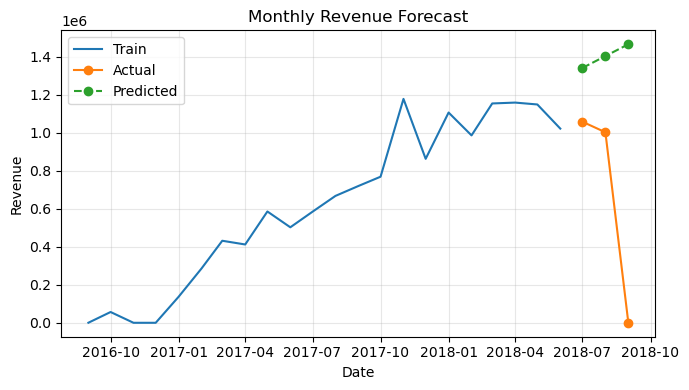

In [13]:
plt.figure(figsize=(7, 4))

# Training data
plt.plot(
    train["purchase_date"],
    train["revenue"],
    label="Train"
)

# Actual values
plt.plot(
    test["purchase_date"],
    test["revenue"],
    marker="o",
    label="Actual"
)

# Predicted values
plt.plot(
    test["purchase_date"],
    test["predicted_revenue"],
    marker="o",
    linestyle="--",
    label="Predicted"
)

plt.title("Monthly Revenue Forecast")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# Calculate evaluation metrics
mae = mean_absolute_error(
    test["revenue"],
    test["predicted_revenue"]
)

rmse = mean_squared_error(
    test["revenue"],
    test["predicted_revenue"]
) ** 0.5

print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")

MAE: 717,228.55
RMSE: 893,080.64


In [15]:
forecast_results = test[
    [
        "purchase_date",
        "revenue",
        "predicted_revenue"
    ]
].copy()

forecast_results.rename(
    columns={
        "purchase_date": "Date",
        "revenue": "Actual Revenue",
        "predicted_revenue": "Predicted Revenue"
    },
    inplace=True
)

display(forecast_results)

,Date,Actual Revenue,Predicted Revenue
22,2018-07-01,1058728.03,1.342373e+06
23,2018-08-01,1003308.47,1.404630e+06
24,2018-09-01,166.46,1.466886e+06


## Business Interpretation

The Linear Regression model captures the overall trend in monthly revenue and provides a simple baseline forecast.

Although the model does not account for seasonality or external factors, it demonstrates the complete forecasting workflow:

- Preparing a time series
- Training a forecasting model
- Evaluating prediction accuracy
- Interpreting business results

For production use, more advanced forecasting models and additional historical data would likely improve prediction accuracy.